# Analysis of the Gun Violence Dataset

# Part 2. &ndash; Exploratory Data Analysis

Authors: Kacper Neumann, Stanisław Apanasiewicz, Jan Matusiak

----


## Setup

We load the raw dataset and apply the corrections identified in `01_problem_and_data_understanding.ipynb` (positive-longitude fix, date parse). Shared helpers (`plot_barplot`, `linreg`, `parse_column`, `parse2`, `index_preprocessing`) live in `utils.py`.


In [1]:
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

from utils import index_preprocessing, linreg, parse2, parse_column, plot_barplot

path = kagglehub.dataset_download('jameslko/gun-violence-data')
df = pd.read_csv(os.path.join(path, 'gun-violence-data_01-2013_03-2018.csv'))
df.set_index('incident_id', inplace=True)

# Fix TSA positive-longitude entries identified in notebook 01.
df['longitude'] = df['longitude'].apply(lambda x: -x if x > 0 else x)

# Parse date for temporal analyses.
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month


/Users/janma/Desktop/gun-violence-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Correlations between numerical attributes


Let's visualize the correlation between attributes: `n_killed`, `n_guns_involved`, `n_injured` and calculate the Pearson r coefficient per pair

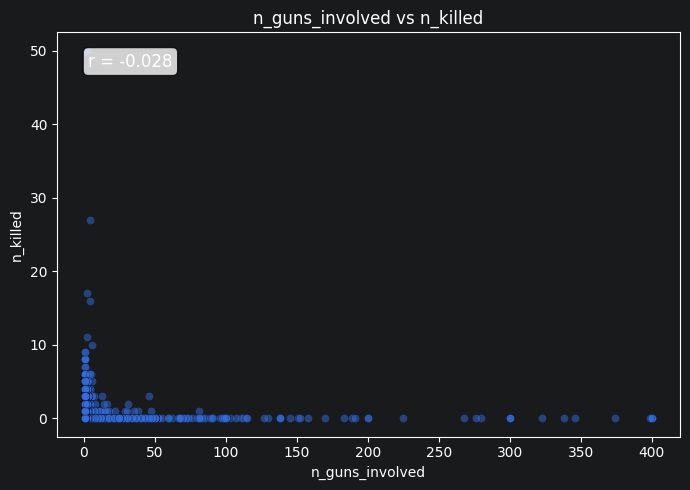

Pearson r : -0.0282


In [4]:
linreg(df['n_guns_involved'], df['n_killed'])

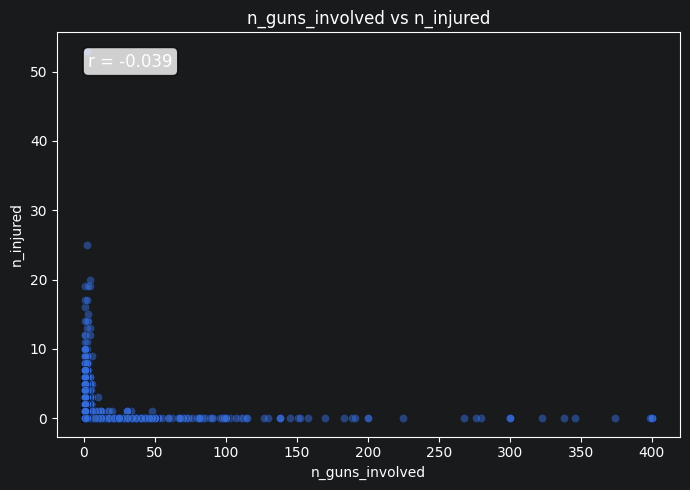

Pearson r : -0.0388


In [5]:
linreg(df['n_guns_involved'], df['n_injured'])

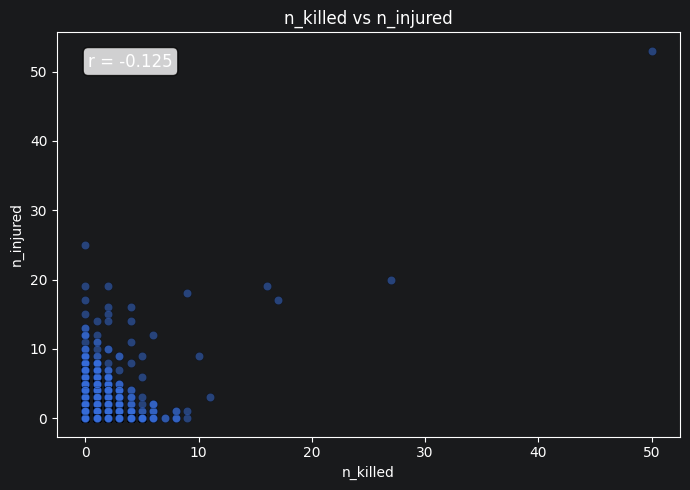

Pearson r : -0.1254


In [6]:
linreg(df['n_killed'], df['n_injured'])

The numerical data are hardly correlated.

## 2. Temporal patterns


In [7]:
df['year'].value_counts()

year
2017    61401
2016    58763
2015    53579
2014    51854
2018    13802
2013      278
Name: count, dtype: int64

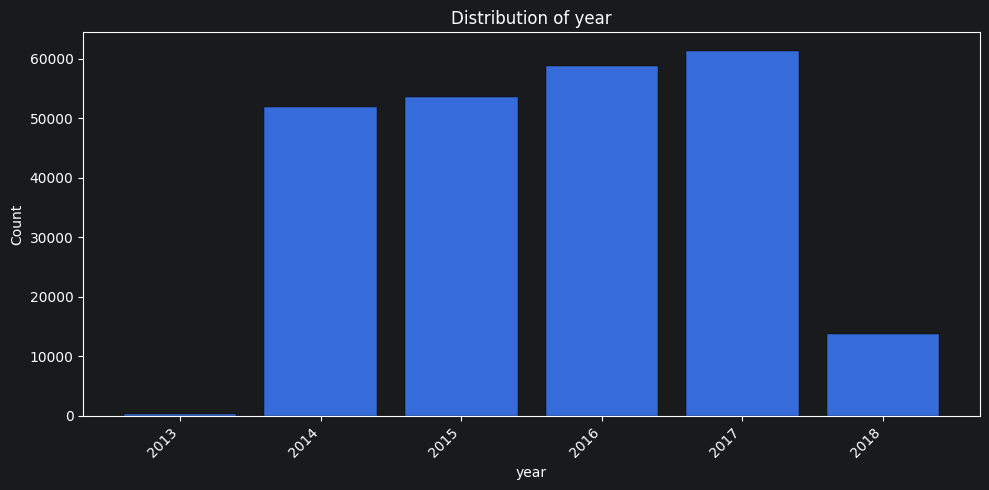

In [8]:
plot_barplot(df['year'])

The dataframe holds information from 01-01-2013 to 31-03-2018, but it seems that in 2013 the incidents were not reported into our dataframe. It seems to be some trend that the number of gun violence rises, however it is hard to tell because of the missing incidents in 2013.

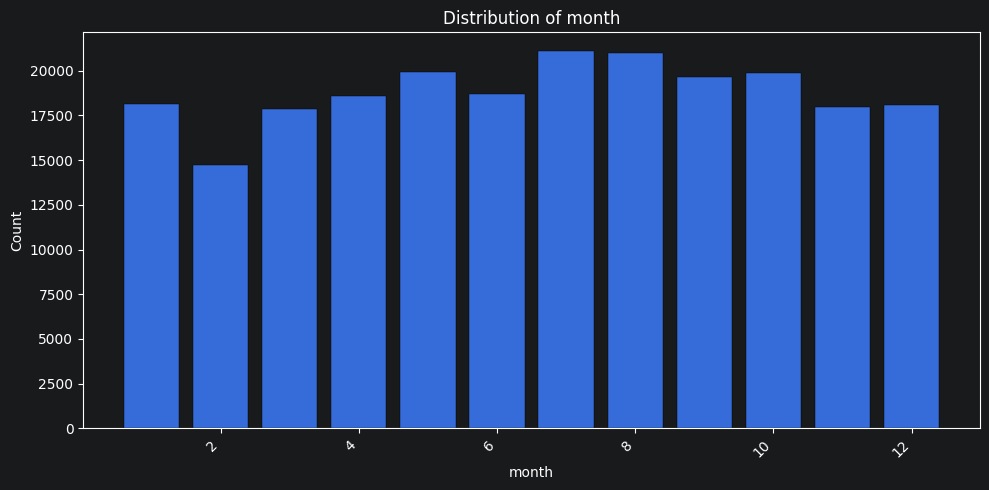

In [9]:
months_years = df[['month', 'year']]
months_years = months_years.loc[months_years['year'] > 2013]
months_years = months_years.loc[months_years['year'] < 2018]
plot_barplot(months_years['month'])

We dropped the data from 2013 because it was incomplete and from 2018 because it contains only 3 months. We can see that a little more gun violence incidents happen in the summer. However, the difference is not substantial.

## 3. Geographic patterns


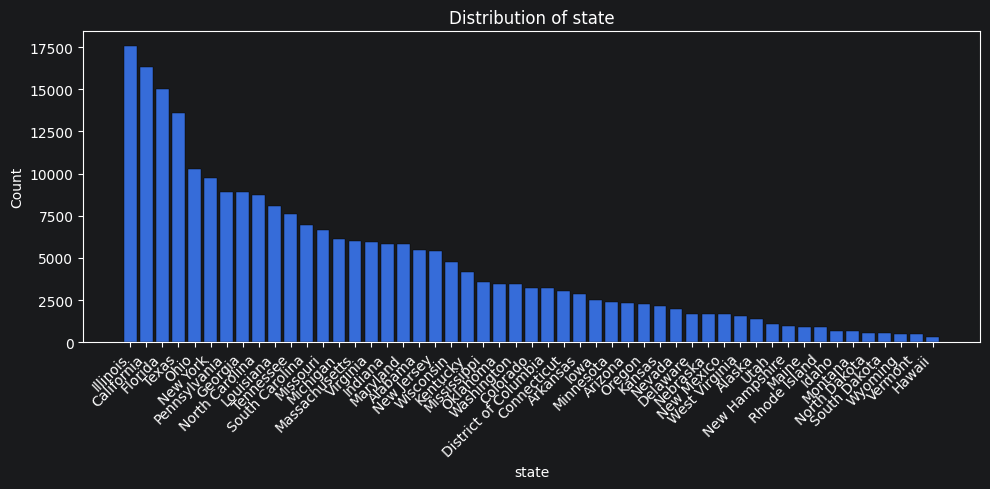

In [10]:
plot_barplot(df['state'])

We have imported some data about the US state population to see which states tend to have the most incidents per capita. The data is from 2015.

In [11]:
df_state = pd.read_csv('US_State_Populations_2015.csv')
df_state.set_index('state', inplace=True)
df_state_counts = df['state'].value_counts()
df_state_counts.name = 'incidents'

df_killed_per_state = df.groupby('state')['n_killed'].sum().sort_values(ascending=False)
df_injured_per_state = df.groupby('state')['n_injured'].sum().sort_values(ascending=False)

df_state = pd.merge(df_state, df_state_counts, left_index=True, right_index=True, how='inner')
df_state = pd.merge(df_state, df_killed_per_state.rename('killed'), left_index=True, right_index=True, how='inner')
df_state = pd.merge(df_state, df_injured_per_state.rename('injured'), left_index=True, right_index=True, how='inner')

df_state['incidents_per_thousand'] = (df_state['incidents'] / df_state['population']) * 1_000
df_state['killed_per_thousand'] = (df_state['killed'] / df_state['population']) * 1_000
df_state['injured_per_thousand'] = (df_state['injured'] / df_state['population']) * 1_000

df_state.sort_values(by='incidents_per_thousand', ascending=False, inplace=True)

In [12]:
usa_incidents_per_thousand = df_state['incidents'].sum() / df_state['population'].sum() * 1_000
print(f"USA incidents per thousand people: {usa_incidents_per_thousand:.2f}")

usa_killed_per_thousand = df_state['killed'].sum() / df_state['population'].sum() * 1_000
print(f"USA killed per thousand people: {usa_killed_per_thousand:.2f}")

usa_injured_per_thousand = df_state['injured'].sum() / df_state['population'].sum() * 1_000
print(f"USA injured per thousand people: {usa_injured_per_thousand:.2f}")

USA incidents per thousand people: 0.75
USA killed per thousand people: 0.19
USA injured per thousand people: 0.37


In [13]:
df_state

,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand
state,,,,,,,
District of Columbia,675400,3195,459,1415,4.730530,0.679597,2.095055
Alaska,737498,1349,267,325,1.829158,0.362035,0.440679
Delaware,941252,1685,217,853,1.790169,0.230544,0.906240
Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840
South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425
Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944
Mississippi,2988471,3599,1176,1883,1.204295,0.393512,0.630088
Tennessee,6591170,7626,1824,4478,1.157002,0.276734,0.679394
Alabama,4852347,5471,1880,2998,1.127496,0.387441,0.617845


In [14]:
import plotly.express as px

df_state2 = df_state.reset_index()   # move 'state' out of the index

us_state_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
}

df_state2["code"] = df_state2["state"].map(us_state_abbrev)

In [15]:
def plot_state_map(df, metric, title, color_scale="Reds"):
    fig = px.choropleth(
        df,
        locations="code",
        locationmode="USA-states",
        scope="usa",
        color=metric,
        color_continuous_scale=color_scale,
        hover_name="state",
        hover_data=["incidents", "killed", "injured", "population"],
        title=title,
    )
    fig.update_layout(title_x=0.5, margin=dict(l=0, r=0, t=60, b=0))
    return fig

plot_state_map(df_state2, "incidents_per_thousand", "Incidents per 1,000 inhabitants").show()
plot_state_map(df_state2, "killed_per_thousand",   "Killings per 1,000 inhabitants", "OrRd").show()
plot_state_map(df_state2, "injured_per_thousand",  "Injuries per 1,000 inhabitants", "YlOrRd").show()

## 4. Participant analysis


### 4.1 Age distribution


In [16]:
age_parsed = parse_column(df, 'participant_age', 'age')

In [17]:
age_parsed = age_parsed.loc[age_parsed['age'] < 120]    # no one lives that long

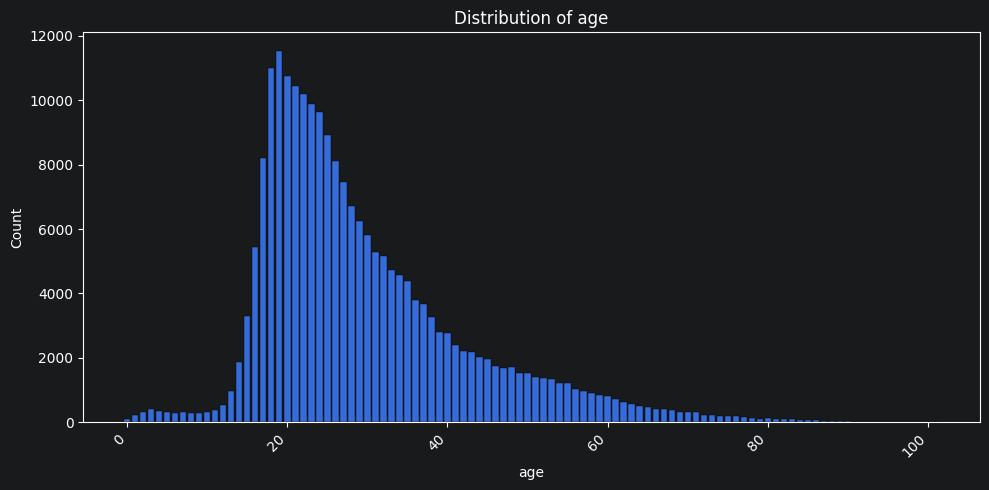

In [18]:
plot_barplot(age_parsed['age'])

We can see that most people in shootings are in their late teens and early twenties, then the number declines with age, but `age` column has a lot of missing values, about twice as much as `age_group`. Let's see it.

In [19]:
df.participant_type.isna().sum()

np.int64(24863)

### 4.2 Age groups, types, status, gender, name


In [20]:
age_group_parsed = parse_column(df, 'participant_age_group', 'age_group', stringed=True)
age_group_parsed['age_group'].value_counts()

age_group
Adult 18+     300616
Teen 12-17     25193
Child 0-11      4472
Name: count, dtype: int64

In [21]:
df.participant_type.value_counts()
type_parsed = parse_column(df, 'participant_type', 'type', stringed=True)
type_parsed['type'].value_counts()

type
Subject-Suspect    195913
Victim             189600
Name: count, dtype: int64

In [22]:
print(df.n_injured.sum() + df.n_killed.sum())

178870


We now see that about half of the people stated in the dataset are not suspects, but victims. These victims can be either killed or injured.

In [23]:
status_parsed = parse_column(df, 'participant_status', 'status', stringed=True)
status_parsed['status'].value_counts()

status
Injured                        113332
Unharmed                       100822
Unharmed, Arrested              85388
Killed                          59386
Arrested                        10169
Injured, Arrested                3467
Killed, Arrested                   51
Injured, Unharmed                  31
Injured, Unharmed, Arrested        22
Killed, Unharmed                   21
Killed, Unharmed, Arrested         14
Killed, Injured                    10
Name: count, dtype: int64

The comma here is not a mistake, because someone can be unharmed and arrested at the same time, but the combinations of 
- killed + unharmed
- killed + injured
- injured + unharmed

do not make sense, we have to delete them. 

In [24]:
gender_parsed = parse_column(df, 'participant_gender', 'gender', stringed=True)
gender_parsed['gender'].value_counts()

gender
Male            304102
Female           42376
Male, female         1
Name: count, dtype: int64

mate could not decide, what a legend

In [25]:
name_parsed = parse_column(df, 'participant_name', 'name', stringed=True)
name_parsed['name'].value_counts()

name
Officer                      536
Deputy                       122
Michael Williams              33
Michael Smith                 31
Christopher Williams          23
                            ... 
Jhkeya Tezeno                  1
Jamal Haskett                  1
Jaquarious Tyjuan Ardison      1
Leroy Ellis                    1
Marie Lancaster Hale           1
Name: count, Length: 161623, dtype: int64

In [26]:
df['participant_name']

incident_id
461105                                        0::Julian Sims
460726                                     0::Bernard Gillis
478855     0::Damien Bell||1::Desmen Noble||2::Herman Sea...
478925     0::Stacie Philbrook||1::Christopher Ratliffe||...
478959     0::Danielle Imani Jameison||1::Maurice Eugene ...
                                 ...                        
1083142                                     0::Jhkeya Tezeno
1083139       0::Jamal Haskett||1::Jaquarious Tyjuan Ardison
1083151                                                  NaN
1082514                                       0::Leroy Ellis
1081940             0::Marie Lancaster Hale||1::William Hale
Name: participant_name, Length: 239677, dtype: str

### 4.3 People per incident


In [27]:
people = type_parsed.position.value_counts()

people2 = people.copy()
for i in range(len(people)-2, -1, -1):
    people[i] -= people2[i+1]
pnp = people.to_numpy()
pnp # how much people were involved in the incident (both victims and perpetrators) 

array([103478,  69556,  23021,   9253,   3636,   1382,    559,    269,
          111,     72,     34,     27,     15,      8,     14,      5,
            8,      4,      5,      6,      3,      3,      1,      4,
            0,      2,      2,      1,      2,      1,      0,      1,
            0,      0,      2,      0,      1,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      1,      0,
            0,      0,      0,      1,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      1,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,      1])

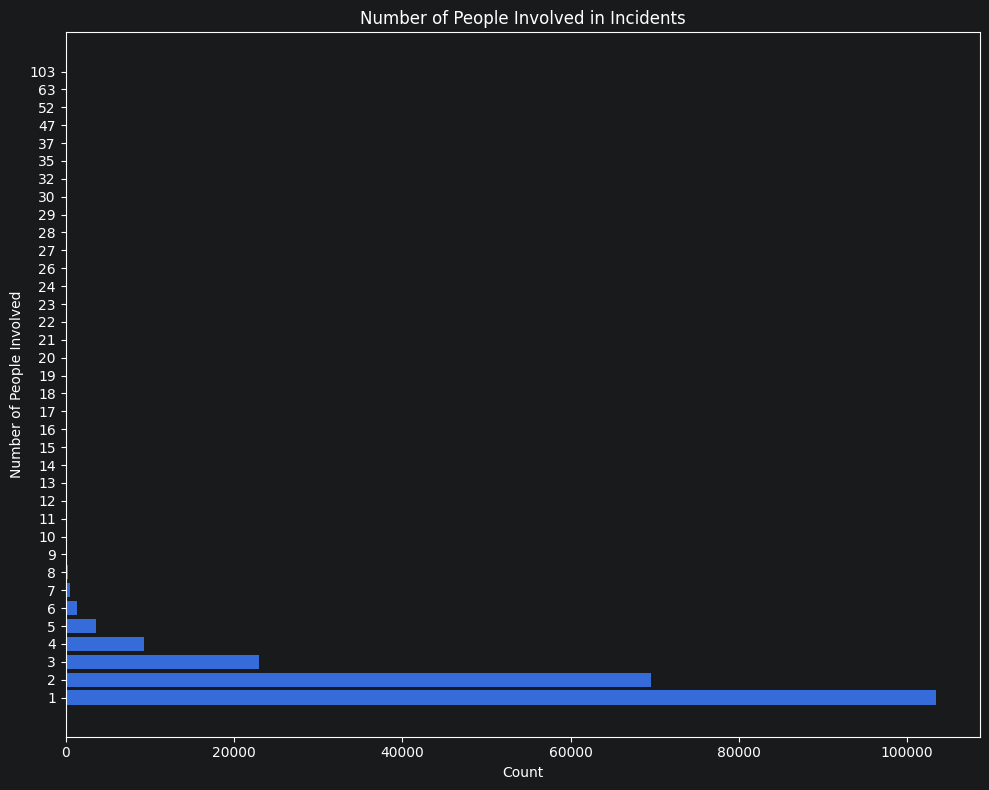

In [28]:
nonzero_mask = pnp > 0
values = pnp[nonzero_mask]
indices = np.where(nonzero_mask)[0] + 1 # original positions as labels

_, ax = plt.subplots(figsize=(10, 8))
ax.barh(indices.astype(str), values)
ax.set_xlabel('Count')
ax.set_ylabel('Number of People Involved')
ax.set_title('Number of People Involved in Incidents')
plt.tight_layout()
plt.show()

We can see that in most cases there was only 1 person involved, however there is a shooting were 103 people took part

### 4.4 Merged per-person DataFrame


In [29]:
index_preprocessing(status_parsed)
index_preprocessing(gender_parsed)
index_preprocessing(type_parsed)
index_preprocessing(age_parsed)
index_preprocessing(age_group_parsed)
index_preprocessing(name_parsed)

In [30]:
person_df = type_parsed.merge(status_parsed[['id', 'status']], on='id', how='left')
person_df = person_df.merge(gender_parsed[['id', 'gender']], on='id', how='left')
person_df = person_df.merge(age_parsed[['id', 'age']], on='id', how='left')
person_df = person_df.merge(age_group_parsed[['id', 'age_group']], on='id', how='left')
person_df = person_df.merge(name_parsed[['id', 'name']], on='id', how='left')

In [31]:
person_df = person_df.set_index('id')

In [32]:
person_df

,original_index,position,type,status,gender,age,age_group,name
id,,,,,,,,
461105p0,461105,0,Victim,Arrested,Male,20.0,Adult 18+,Julian Sims
461105p1,461105,1,Victim,Injured,Male,NaN,Adult 18+,NaN
461105p2,461105,2,Victim,Injured,NaN,NaN,Adult 18+,NaN
461105p3,461105,3,Victim,Injured,Male,NaN,Adult 18+,NaN
461105p4,461105,4,Subject-Suspect,Injured,Female,NaN,Adult 18+,NaN
...,...,...,...,...,...,...,...,...
1083139p1,1083139,1,Subject-Suspect,"Unharmed, Arrested",Male,21.0,Adult 18+,Jaquarious Tyjuan Ardison
1083151p0,1083151,0,Victim,Injured,Male,21.0,Adult 18+,NaN
1082514p0,1082514,0,Victim,Killed,Male,42.0,Adult 18+,Leroy Ellis


### 4.5 Victim vs suspect age


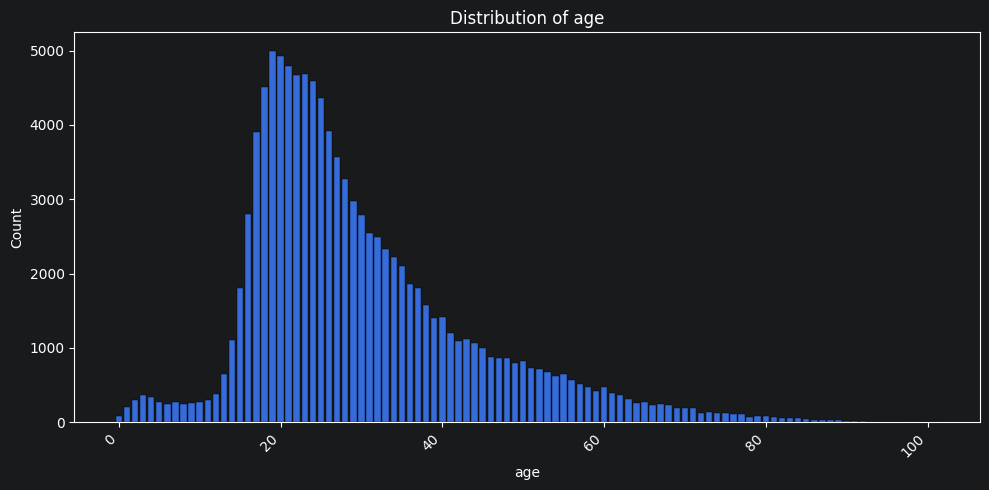

29.77 mean victim age
26.0 median victim age
13.94 standard deviation of victim age


In [33]:
plot_barplot(person_df[person_df['type'] == 'Victim']['age'])
print(person_df[person_df['type'] == 'Victim']['age'].mean().round(2), "mean victim age")
print(person_df[person_df['type'] == 'Victim']['age'].median(), "median victim age")
print(person_df[person_df['type'] == 'Victim']['age'].std().round(2), "standard deviation of victim age")

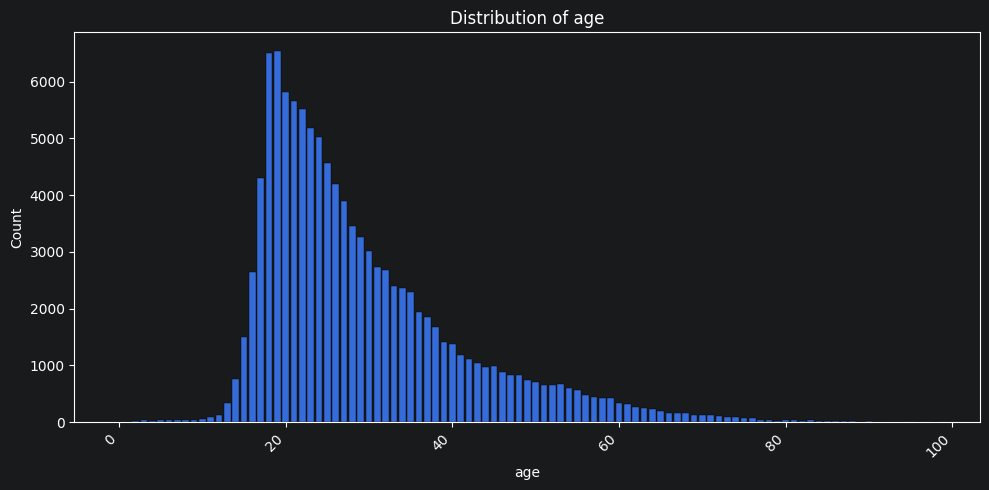

29.18 mean subject-suspect age
26.0 median subject-suspect age
12.21 standard deviation of subject-suspect age


In [34]:
plot_barplot(person_df[person_df['type'] == 'Subject-Suspect']['age'])
print(person_df[person_df['type'] == 'Subject-Suspect']['age'].mean().round(2), "mean subject-suspect age")
print(person_df[person_df['type'] == 'Subject-Suspect']['age'].median(), "median subject-suspect age")
print(person_df[person_df['type'] == 'Subject-Suspect']['age'].std().round(2), "standard deviation of subject-suspect age")

We can see that median and mean of suspects and victims are similar, the most different here is the spread. We can see that bigger portion of suspects are in the age 15-30 than victims. More victims are kids and older people. We can also see that sometimes children below 5 are suspects.

## 5. Firearms


In [35]:
gun_parsed = parse_column(df, 'gun_type', 'gun', stringed=True)

In [36]:
print(gun_parsed['gun'].nunique() - 1, "recognised gun types + one category for other")

26 recognised gun types + one category for other


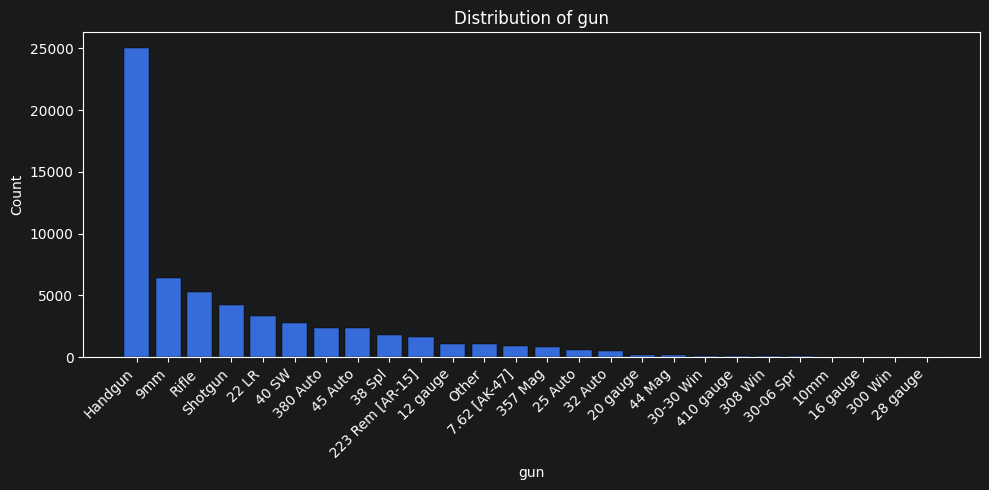

In [37]:
plot_barplot(gun_parsed[gun_parsed['gun'] != 'Unknown']['gun'])

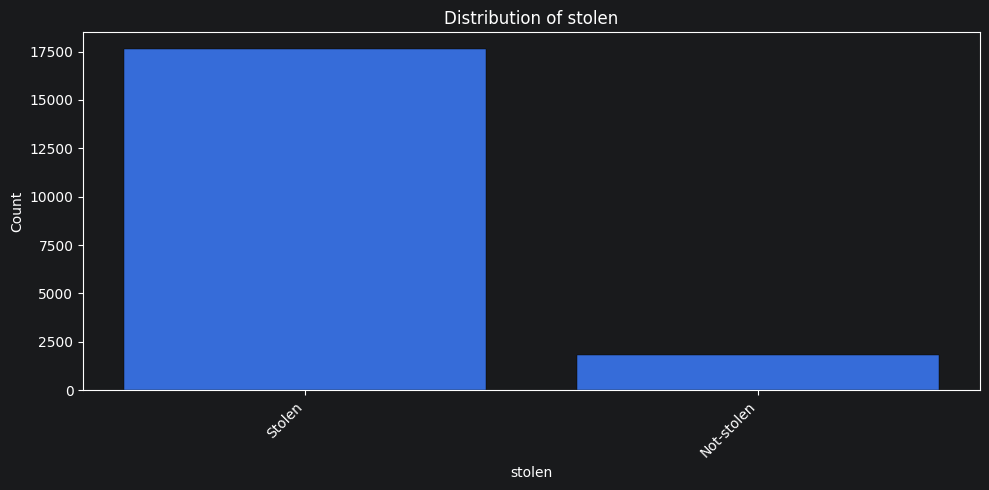

In [38]:
gun_stolen_parsed = parse_column(df, 'gun_stolen', 'stolen', stringed=True)
plot_barplot(gun_stolen_parsed[gun_stolen_parsed['stolen'] != 'Unknown']['stolen'])

We can see that most of the guns are unknown, but there are mostly handguns and smaller guns. Also, most of the times a gun is stolen (about 7-8 times more). For both bars we excluded the "Unknown" category. Most of the times the data is missing or there is no information about the gun.

## 6. Incident characteristics


In [39]:
notes_parsed = parse2(df, 'incident_characteristics')


In [40]:
pd.set_option('display.max_rows', None)

notes_parsed['incident_characteristics'].value_counts()

incident_characteristics
Shot - Wounded/Injured                                                                                  93926
Shot - Dead (murder, accidental, suicide)                                                               53409
Non-Shooting Incident                                                                                   44837
Shots Fired - No Injuries                                                                               35750
Possession (gun(s) found during commission of other crimes)                                             30863
Armed robbery with injury/death and/or evidence of DGU found                                            19723
Brandishing/flourishing/open carry/lost/found                                                           19017
ATF/LE Confiscation/Raid/Arrest                                                                         17991
Officer Involved Incident                                                                      

In [41]:
print("there are", notes_parsed['incident_characteristics'].nunique(), "unique incident characteristics")

there are 109 unique incident characteristics


This attribute is not that useful for us because we have 109 categories here. However, it explains the little kids in suspect section. They were playing with their parent's gun.